In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
df = pd.read_excel("GoogleReviews-DomesticViolence.xlsx")

In [ ]:
print(df.shape)
print(df.columns.tolist())

(71349, 31)
['query', 'name', 'google_id', 'place_id', 'location_link', 'reviews_link', 'reviews_per_score', 'reviews', 'rating', 'review_id', 'review_pagination_id', 'author_link', 'author_id', 'author_image', 'author_reviews_count', 'author_photos_count', 'author_ratings_count', 'review_text', 'review_img_urls', 'review_img_url', 'review_questions', 'review_photo_ids', 'owner_answer', 'owner_answer_timestamp', 'owner_answer_timestamp_datetime_utc', 'review_link', 'review_rating', 'review_timestamp', 'review_datetime_utc', 'review_likes', 'reviews_id']


In [ ]:
df.describe()

,reviews,rating,author_reviews_count,author_photos_count,author_ratings_count,review_questions,owner_answer_timestamp,review_rating,review_timestamp,review_likes,reviews_id
count,64127.000000,70694.000000,70688.000000,70601.000000,87.000000,0.0,2.000000e+00,70688.000000,7.068800e+04,0.0,6.288800e+04
mean,69.539648,4.036027,31.391311,46.233424,34.011494,NaN,1.736450e+09,4.005050,1.672041e+09,NaN,7.000138e+16
std,136.831788,0.734904,77.277797,482.165416,82.396022,NaN,6.716587e+06,1.604611,8.176422e+07,NaN,5.263438e+18
min,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,1.731700e+09,1.000000,1.290219e+09,NaN,-9.222292e+18
25%,19.000000,3.600000,2.000000,0.000000,1.000000,NaN,1.734075e+09,3.000000,1.615920e+09,NaN,-4.507050e+18
50%,37.000000,4.200000,7.000000,0.000000,3.000000,NaN,1.736450e+09,5.000000,1.694549e+09,NaN,3.309355e+17
75%,70.000000,4.600000,28.000000,5.000000,21.000000,NaN,1.738824e+09,5.000000,1.741893e+09,NaN,4.523415e+18
max,3753.000000,5.000000,4671.000000,37591.000000,545.000000,NaN,1.741199e+09,5.000000,1.771562e+09,NaN,9.218763e+18


In [ ]:
total_reviews = len(df)
non_missing_text = df["review_text"].notna().sum()
missing_text = df["review_text"].isna().sum()
missing_pct = (missing_text / total_reviews) * 100

print("Total reviews:", total_reviews)
print("Reviews containing text:", non_missing_text)
print("Reviews without text:", missing_text)
print("Percentage (No Text): {:.2f}%".format(missing_pct))

Total reviews: 71349
Reviews containing text: 45298
Reviews without text: 26051
Percentage (No Text): 36.51%


In [ ]:
# Extract U.S. state abbreviation from the query string
df['state'] = df['query'].str.extract(r',\s([A-Z]{2}),\s*US')

# Map abbreviation to full state name
state_names = {'IL': 'Illinois', 'WA': 'Washington',
               'AZ': 'Arizona',  'KY': 'Kentucky', 'OK': 'Oklahoma'}
df['state_name'] = df['state'].map(state_names)

# Parse datetime and extract year
df['review_datetime_utc'] = pd.to_datetime(df['review_datetime_utc'], errors='coerce')
df['review_year'] = df['review_datetime_utc'].dt.year

# Binary features
df['has_owner_response'] = df['owner_answer'].notna()
df['has_review_text'] = df['review_text'].notna()

# Drop rows with missing review_rating
df_model = df.dropna(subset=['review_rating']).copy()

# Response rate per state
state_response = (df.groupby('state_name')['has_owner_response'].mean().reindex(['Illinois', 'Washington', 'Arizona', 'Kentucky', 'Oklahoma'])* 100)

In [ ]:
# Rows after dropping missing ratings
print(df_model.shape[0])

70688


In [ ]:
# Facility-level aggregates
facility_stats = df.groupby('name').agg(
    avg_rating      = ('review_rating', 'mean'),
    total_reviews   = ('review_id', 'count'),
    response_rate   = ('has_owner_response', 'mean'),
    pct_1star       = ('review_rating', lambda x: (x == 1).mean()),
    pct_5star       = ('review_rating', lambda x: (x == 5).mean()),
    state           = ('state_name', 'first')
).reset_index()

# Keep only facilities with at least 10 reviews or more
facility_stats = facility_stats[facility_stats['total_reviews'] >= 10].copy()
print(len(facility_stats))

2500


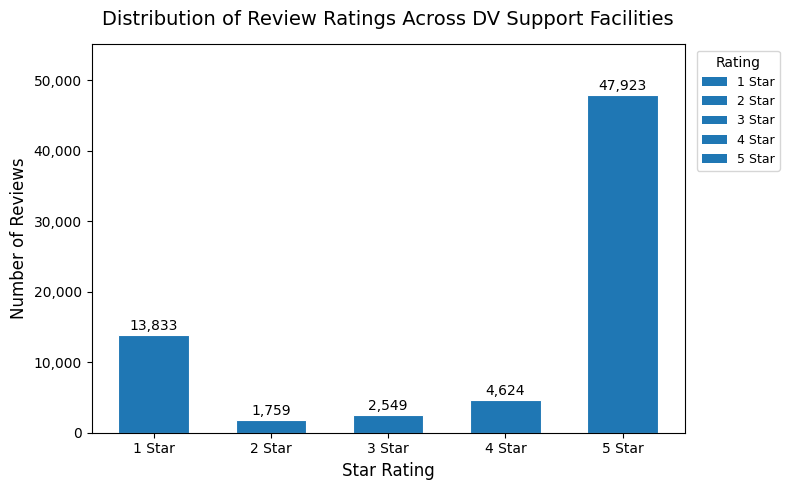

In [ ]:
# Review Rating Distribution
fig, ax = plt.subplots(figsize=(8, 5))
rating_counts = df['review_rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index.astype(int), rating_counts.values,
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribution of Review Ratings Across DV Support Facilities',
             fontsize=14, pad=14)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1 Star', '2 Star', '3 Star', '4 Star', '5 Star'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
legend_patches = [plt.Rectangle((0,0),1,1, label=f'{i+1} Star') for i in range(5)]
ax.legend(handles=legend_patches, title='Rating',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, rating_counts.max() * 1.15)
plt.tight_layout()
plt.show()

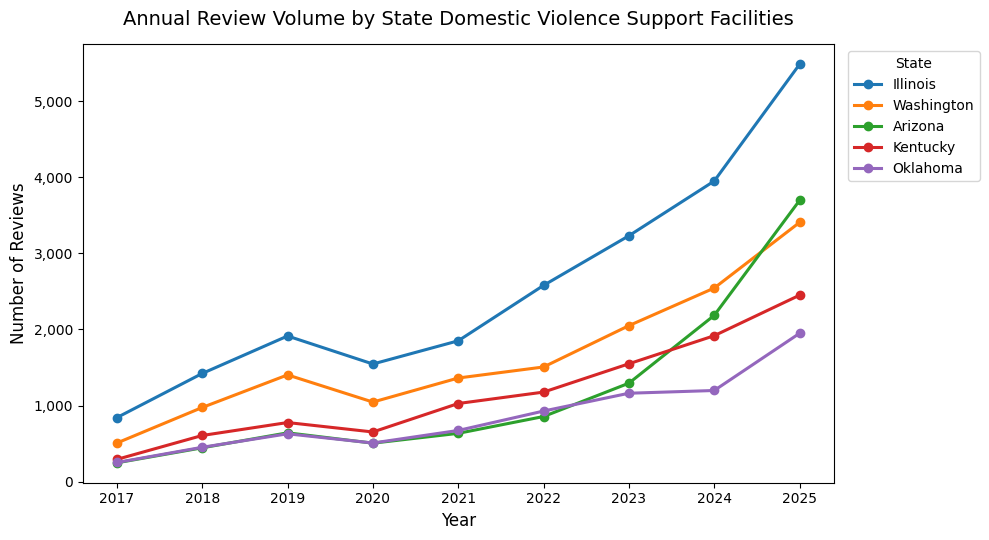

In [ ]:
yearly_state = (df[df['review_year'].between(2017, 2025)]
                .groupby(['review_year', 'state_name'])
                .size().reset_index(name='count'))
fig, ax = plt.subplots(figsize=(10, 5.5))
for i, state in enumerate(['Illinois', 'Washington', 'Arizona', 'Kentucky', 'Oklahoma']):
    sub = yearly_state[yearly_state['state_name'] == state]
    ax.plot(sub['review_year'], sub['count'], marker='o', linewidth=2.2,
            markersize=6, label=state)
ax.set_title('Annual Review Volume by State Domestic Violence Support Facilities',
             fontsize=14, pad=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xticks(range(2017, 2026))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

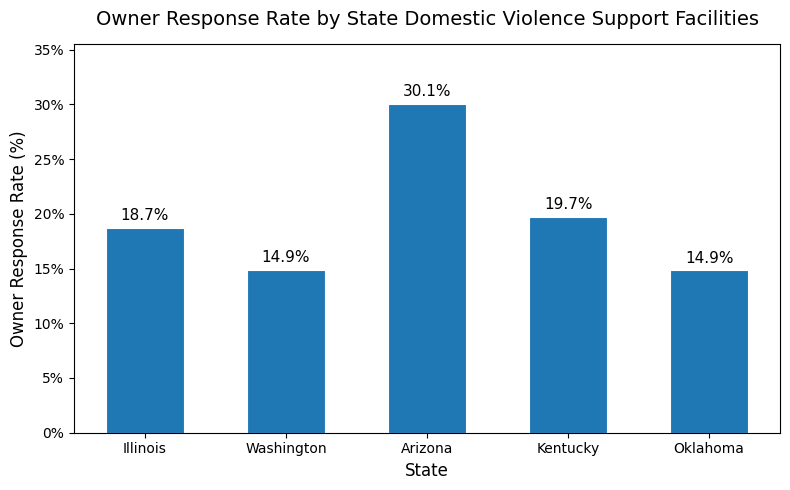

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(state_response.index, state_response.values,
              edgecolor='white', linewidth=0.8, width=0.55)

for bar, val in zip(bars, state_response.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Owner Response Rate by State Domestic Violence Support Facilities',
             fontsize=14, pad=14)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Owner Response Rate (%)', fontsize=12)
ax.set_ylim(0, state_response.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

In [ ]:
print(f"Goal 1 target distribution:\n"
      f"  Positive (4-5 Stars): {(df_model['review_rating'] >= 4).sum():,}\n"
      f"  Negative (1-2 Stars): {(df_model['review_rating'] <= 2).sum():,}\n"
      f"  Neutral  (3 Stars):   {(df_model['review_rating'] == 3).sum():,}")

Goal 1 target distribution:
  Positive (4-5 Stars): 52,547
  Negative (1-2 Stars): 15,592
  Neutral  (3 Stars):   2,549


In [ ]:
print(f"Goal 1 target distribution:\n"
      f"  Positive (4-5 Stars): {(df_model['review_rating'] >= 4).sum():,}\n"
      f"  Negative (1-3 Stars): {(df_model['review_rating'] <= 3).sum():,}\n")

Goal 1 target distribution:
  Positive (4-5 Stars): 52,547
  Negative (1-3 Stars): 18,141



In [ ]:
# filter reviews with text only
df = df[df['review_text'].notna() & (df['review_text'].str.strip() != "")]

# length of reviews
df["review_length"] = df["review_text"].str.len()

# check missing ratings
df['review_rating'].isna().sum()

df = df.dropna(subset=['review_rating'])

# binary class variable
df["sentiment"] = (df["review_rating"] >= 4).astype(int)

# one-hot encode state variable
df = pd.get_dummies(df, columns=["state_name"], drop_first=True)

# Goal 1 - Predictive Task

In [ ]:
# X and y
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)

X = vectorizer.fit_transform(df["review_text"]).toarray()

X = np.hstack((
    X,
    df[[
        "author_reviews_count",
        "has_owner_response",
        "review_year",
        "review_length"
    ]].fillna(0).values
))

y = df["sentiment"]

In [ ]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2713
           1       0.95      0.91      0.93      6347

    accuracy                           0.91      9060
   macro avg       0.88      0.90      0.89      9060
weighted avg       0.91      0.91      0.91      9060

[[2433  280]
 [ 566 5781]]


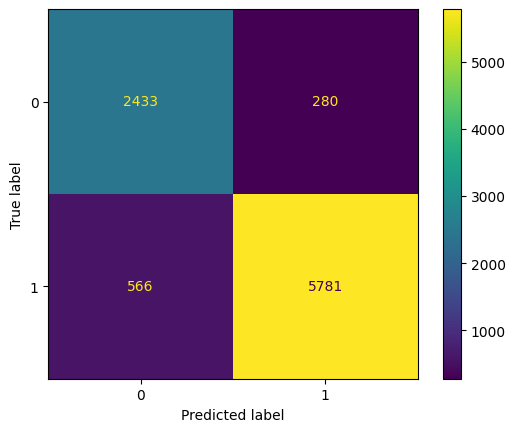

In [ ]:
# confusion matrix - logistic regression
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)

In [ ]:
# random forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      2713
           1       0.91      0.96      0.93      6347

    accuracy                           0.90      9060
   macro avg       0.90      0.87      0.88      9060
weighted avg       0.90      0.90      0.90      9060

[[2122  591]
 [ 278 6069]]


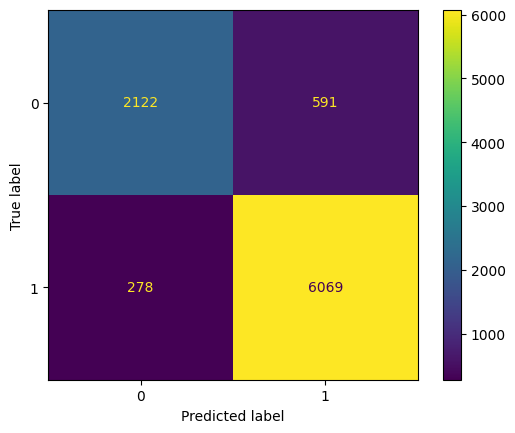

In [ ]:
# confusion matrix - random forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

In [ ]:
# xgboost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2713
           1       0.90      0.97      0.93      6347

    accuracy                           0.90      9060
   macro avg       0.90      0.86      0.88      9060
weighted avg       0.90      0.90      0.90      9060

[[2056  657]
 [ 214 6133]]


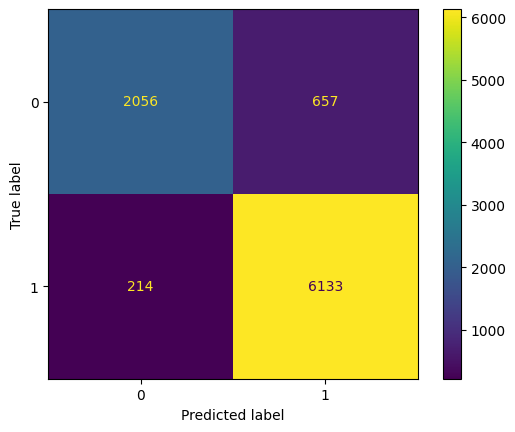

In [ ]:
# confusion matrix - xgboost
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred)

In [ ]:
# model comparison
results = pd.DataFrame([
    {
        "model": "logistic regression",
        "accuracy": accuracy_score(y_test, lr_pred),
        "precision": precision_score(y_test, lr_pred),
        "recall": recall_score(y_test, lr_pred),
        "f1": f1_score(y_test, lr_pred)
    },
    {
        "model": "random forest",
        "accuracy": accuracy_score(y_test, rf_pred),
        "precision": precision_score(y_test, rf_pred),
        "recall": recall_score(y_test, rf_pred),
        "f1": f1_score(y_test, rf_pred)
    },
    {
        "model": "xgboost",
        "accuracy": accuracy_score(y_test, xgb_pred),
        "precision": precision_score(y_test, xgb_pred),
        "recall": recall_score(y_test, xgb_pred),
        "f1": f1_score(y_test, xgb_pred)
    }
])

print("Model Comparison")
print(results.sort_values(by="f1", ascending=False))

Model Comparison
                 model  accuracy  precision    recall        f1
2              xgboost  0.903863   0.903240  0.966283  0.933699
1        random forest  0.904084   0.911261  0.956200  0.933190
0  logistic regression  0.906623   0.953803  0.910824  0.931818


# Goal 2 - Non-predictive Task

In [ ]:
# Set themes
themes = {
    "support": ["help", "helpful", "care"],
    "staff": ["staff", "friendly"],
    "gratitude": ["thank", "love", "amazing", "wonderful"],
    "urgency": ["time", "need"],
    "general": ["place", "good", "great", "nice"]
}

In [ ]:
# for each theme we set, mark if the review contains any of the words
for theme, words in themes.items():
    pattern = "|".join(words)
    df[f"theme_{theme}"] = df["review_text"].str.contains(pattern, case=False, na=False)

In [ ]:
# split before and after 2020
before = df[df["review_year"] < 2020]
after = df[df["review_year"] >= 2020]

print(before.shape)
print(after.shape)

(6508, 46)
(38790, 46)


In [ ]:
def top_words(text, n=20):
    vec = TfidfVectorizer(stop_words="english", max_features=1000, min_df=5, token_pattern=r'(?u)\b[a-zA-Z]{3,}\b')
    X = vec.fit_transform(text)

    scores = X.mean(axis=0).A1
    words = vec.get_feature_names_out()

    top = scores.argsort()[::-1][:n]

    return pd.DataFrame({
        "word": words[top],
        "score": scores[top]
    })

In [ ]:
top_before = top_words(before["review_text"], 15)
top_after = top_words(after["review_text"], 15)

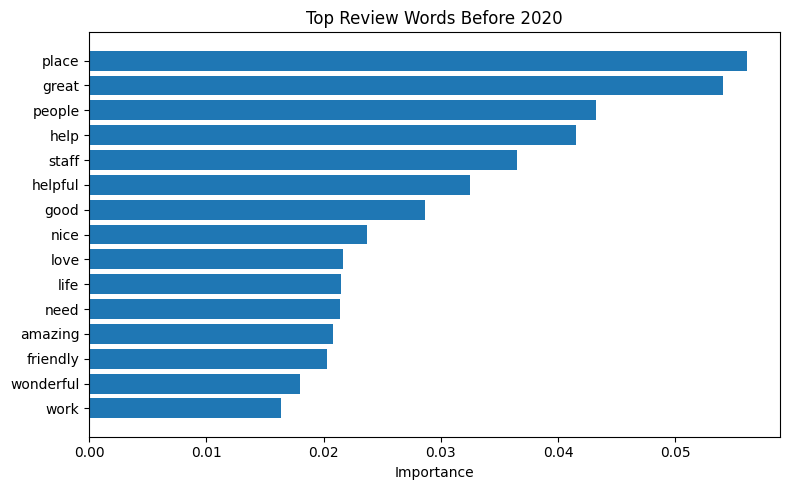

In [ ]:
# before 2020
plt.figure(figsize=(8,5))
plt.barh(top_before["word"][::-1], top_before["score"][::-1])
plt.title("Top Review Words Before 2020")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

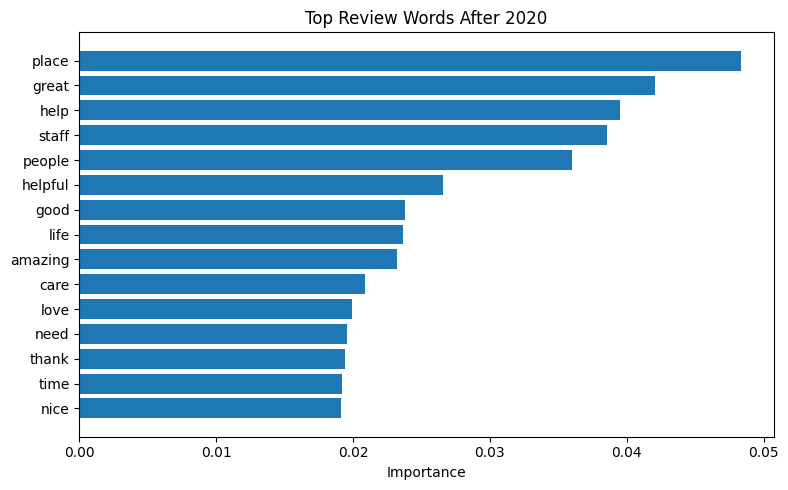

In [ ]:
# after 2020
plt.figure(figsize=(8,5))
plt.barh(top_after["word"][::-1], top_after["score"][::-1])
plt.title("Top Review Words After 2020")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
print("Top words BEFORE 2020:")
print(top_before)

print("\nTop words AFTER 2020:")
print(top_after)

Top words BEFORE 2020:
         word     score
0       place  0.056110
1       great  0.054093
2      people  0.043187
3        help  0.041480
4       staff  0.036447
5     helpful  0.032466
6        good  0.028686
7        nice  0.023737
8        love  0.021620
9        life  0.021493
10       need  0.021354
11    amazing  0.020825
12   friendly  0.020317
13  wonderful  0.017962
14       work  0.016324

Top words AFTER 2020:
       word     score
0     place  0.048334
1     great  0.042081
2      help  0.039490
3     staff  0.038581
4    people  0.035970
5   helpful  0.026553
6      good  0.023787
7      life  0.023625
8   amazing  0.023231
9      care  0.020864
10     love  0.019933
11     need  0.019581
12    thank  0.019404
13     time  0.019228
14     nice  0.019132


In [ ]:
# build a table of insights
results = []

for theme in themes.keys():
    col = f"theme_{theme}"

    # counts
    before_count = before[col].sum()
    after_count = after[col].sum()

    # percentages
    before_pct = before[col].mean()
    after_pct = after[col].mean()

    # subset where theme appears
    subset = df[df[col]]

    avg_rating = subset["review_rating"].mean()
    pct_positive = subset["sentiment"].mean()
    response_rate = subset["has_owner_response"].mean()
    avg_length = subset["review_length"].mean()

    # change metrics
    abs_change = after_pct - before_pct

    rel_change = abs_change / before_pct if before_pct != 0 else None

    results.append({
        "Theme": theme,
        "Before Count": before_count,
        "After Count": after_count,
        "Before %": before_pct,
        "After %": after_pct,
        "Absolute Change": abs_change,
        "Relative Change": rel_change,
        "Avg Rating": avg_rating,
        "Positive %": pct_positive,
        "Response Rate": response_rate,
        "Avg Length": avg_length
    })

theme_table = pd.DataFrame(results)
theme_table

,Theme,Before Count,After Count,Before %,After %,Absolute Change,Relative Change,Avg Rating,Positive %,Response Rate,Avg Length
0,support,2481,17631,0.381223,0.454524,0.073301,0.192279,3.867243,0.711068,0.272673,447.061506
1,staff,1307,9866,0.200830,0.254344,0.053514,0.266465,4.098989,0.769981,0.319789,457.718518
2,gratitude,1556,11648,0.239090,0.300284,0.061193,0.255942,4.620115,0.903968,0.314147,405.591033
3,urgency,1493,11575,0.229410,0.298402,0.068992,0.300735,3.450566,0.596572,0.278160,599.079660
4,general,3013,17949,0.462969,0.462722,-0.000246,-0.000532,3.956731,0.734186,0.257418,390.262857


In [ ]:
p_values = []

for theme in themes.keys():
    col = f"theme_{theme}"

    count = [before[col].sum(), after[col].sum()]
    nobs = [len(before), len(after)]

    stat, p = proportions_ztest(count, nobs)
    p_values.append(p)

theme_table["p_value"] = p_values
theme_table["Significant (p < 0.05)"] = theme_table["p_value"] < 0.05

In [ ]:
theme_table["Before %"] = theme_table["Before %"] * 100
theme_table["After %"] = theme_table["After %"] * 100
theme_table["Positive %"] = theme_table["Positive %"] * 100
theme_table["Response Rate"] = theme_table["Response Rate"] * 100
theme_table["Absolute Change"] = theme_table["Absolute Change"] * 100
theme_table["Relative Change"] = theme_table["Relative Change"] * 100

In [ ]:
theme_table

,Theme,Before Count,After Count,Before %,After %,Absolute Change,Relative Change,Avg Rating,Positive %,Response Rate,Avg Length,p_value,Significant (p < 0.05)
0,support,2481,17631,38.122311,45.452436,7.330125,19.227914,3.867243,71.106802,27.267303,447.061506,3.287868e-28,True
1,staff,1307,9866,20.082975,25.434390,5.351416,26.646528,4.098989,76.998120,31.978878,457.718518,1.902543e-20,True
2,gratitude,1556,11648,23.909035,30.028358,6.119323,25.594186,4.620115,90.396849,31.414723,405.591033,8.982349e-24,True
3,urgency,1493,11575,22.940996,29.840165,6.899169,30.073539,3.450566,59.657178,27.816039,599.079660,6.033301e-30,True
4,general,3013,17949,46.296865,46.272235,-0.024630,-0.053201,3.956731,73.418567,25.741819,390.262857,9.705833e-01,False


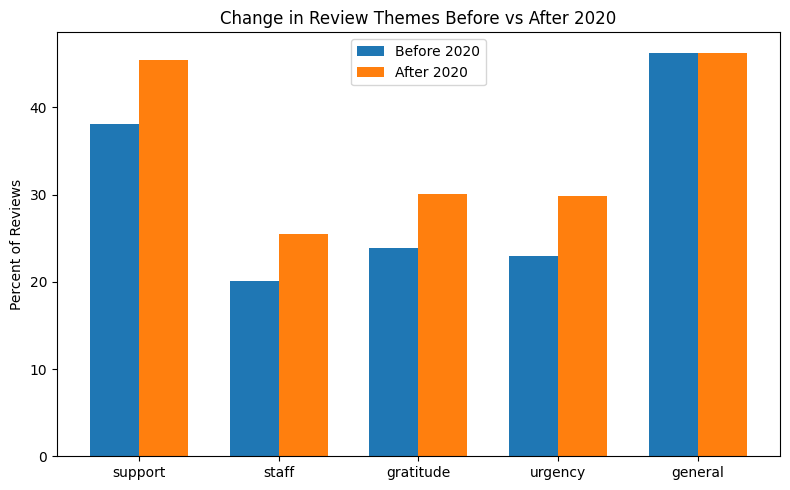

In [ ]:
# change in theme before 2020 and after 2020

themes = theme_table["Theme"]
before = theme_table["Before %"]
after = theme_table["After %"]

x = range(len(themes))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar([i - width/2 for i in x], before, width, label="Before 2020")
plt.bar([i + width/2 for i in x], after, width, label="After 2020")

plt.xticks(x, themes)
plt.ylabel("Percent of Reviews")
plt.title("Change in Review Themes Before vs After 2020")
plt.legend()

plt.tight_layout()
plt.show()

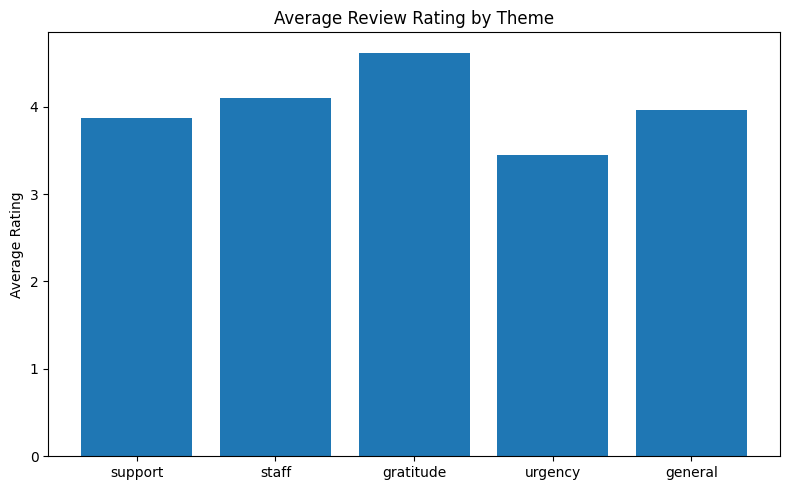

In [ ]:
# average rating by theme

plt.figure(figsize=(8,5))

plt.bar(themes, theme_table["Avg Rating"])

plt.ylabel("Average Rating")
plt.title("Average Review Rating by Theme")

plt.tight_layout()
plt.show()

In [ ]:
response_table = theme_table[["Theme", "Response Rate"]].copy()
response_table = response_table.sort_values("Response Rate", ascending=True)

print(response_table)

       Theme  Response Rate
4    general      25.741819
0    support      27.267303
3    urgency      27.816039
2  gratitude      31.414723
1      staff      31.978878


In [ ]:
results = []

for theme in themes.keys():
    col = f"theme_{theme}"

    # before 2020
    before_subset = before[before[col]]
    before_total = len(before_subset)
    before_positive = before_subset["sentiment"].sum()
    before_negative = before_total - before_positive

    # after 2020
    after_subset = after[after[col]]
    after_total = len(after_subset)
    after_positive = after_subset["sentiment"].sum()
    after_negative = after_total - after_positive

    results.append({
        "Theme": theme,

        "Before Total": before_total,
        "Before Positive": before_positive,
        "Before Negative": before_negative,

        "After Total": after_total,
        "After Positive": after_positive,
        "After Negative": after_negative,

        "Before Positive %": (before_positive / before_total * 100) if before_total > 0 else 0,
        "After Positive %": (after_positive / after_total * 100) if after_total > 0 else 0
    })

theme_sentiment_time = pd.DataFrame(results)
theme_sentiment_time

,Theme,Before Total,Before Positive,Before Negative,After Total,After Positive,After Negative,Before Positive %,After Positive %
0,support,2481,1878,603,17631,12423,5208,75.695284,70.461120
1,staff,1307,1029,278,9866,7574,2292,78.729916,76.768701
2,gratitude,1556,1438,118,11648,10498,1150,92.416452,90.127060
3,urgency,1493,905,588,11575,6891,4684,60.616209,59.533477
4,general,3013,2317,696,17949,13073,4876,76.900100,72.834141


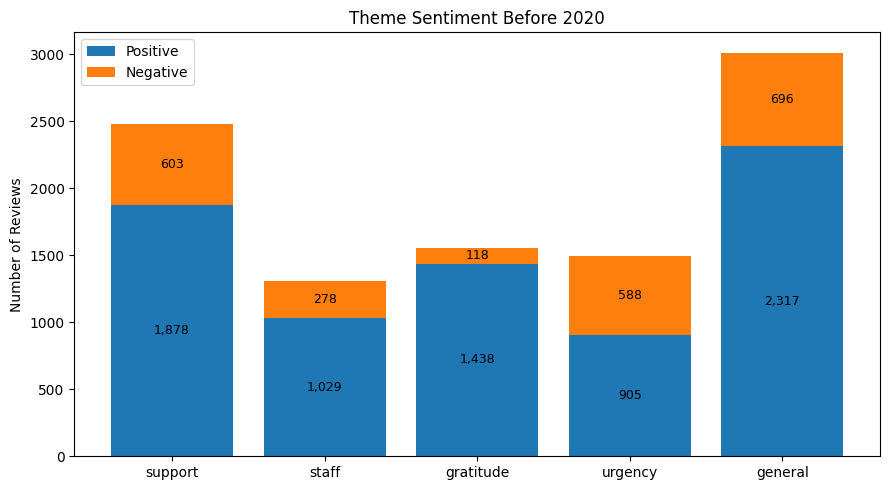

In [ ]:
themes = theme_sentiment_time["Theme"]

before_pos = theme_sentiment_time["Before Positive"]
before_neg = theme_sentiment_time["Before Negative"]

after_pos = theme_sentiment_time["After Positive"]
after_neg = theme_sentiment_time["After Negative"]

# before 2020
plt.figure(figsize=(9,5))

bars1 = plt.bar(themes, before_pos, label="Positive")
bars2 = plt.bar(themes, before_neg, bottom=before_pos, label="Negative")

# add labels to positive segment
for i, (p, n) in enumerate(zip(before_pos, before_neg)):
    plt.text(i, p / 2, f"{int(p):,}", ha="center", va="center", fontsize=9)
    plt.text(i, p + n / 2, f"{int(n):,}", ha="center", va="center", fontsize=9)

plt.ylabel("Number of Reviews")
plt.title("Theme Sentiment Before 2020")
plt.legend()
plt.tight_layout()
plt.show()

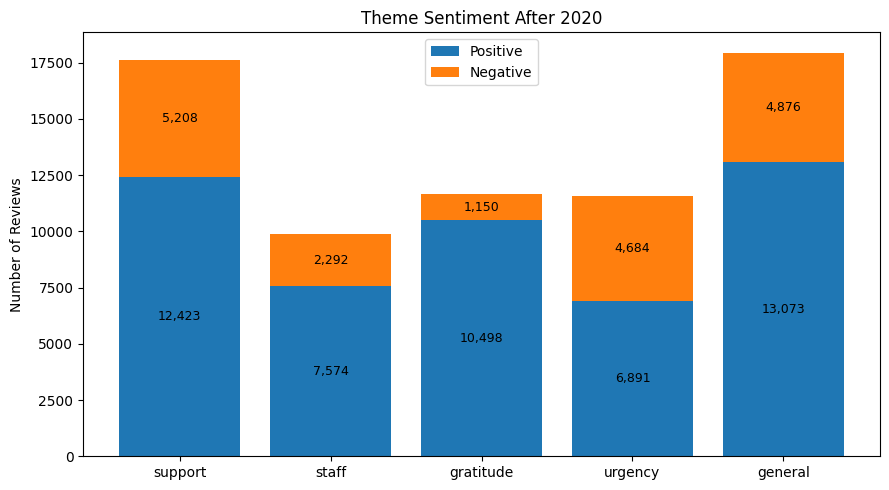

In [ ]:
# after 2020
plt.figure(figsize=(9,5))

bars1 = plt.bar(themes, after_pos, label="Positive")
bars2 = plt.bar(themes, after_neg, bottom=after_pos, label="Negative")

# add labels to positive and negative segments
for i, (p, n) in enumerate(zip(after_pos, after_neg)):
    plt.text(i, p / 2, f"{int(p):,}", ha="center", va="center", fontsize=9)
    plt.text(i, p + n / 2, f"{int(n):,}", ha="center", va="center", fontsize=9)

plt.ylabel("Number of Reviews")
plt.title("Theme Sentiment After 2020")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
overall_avg = df["review_rating"].mean()
print(overall_avg)

3.8359971742681798


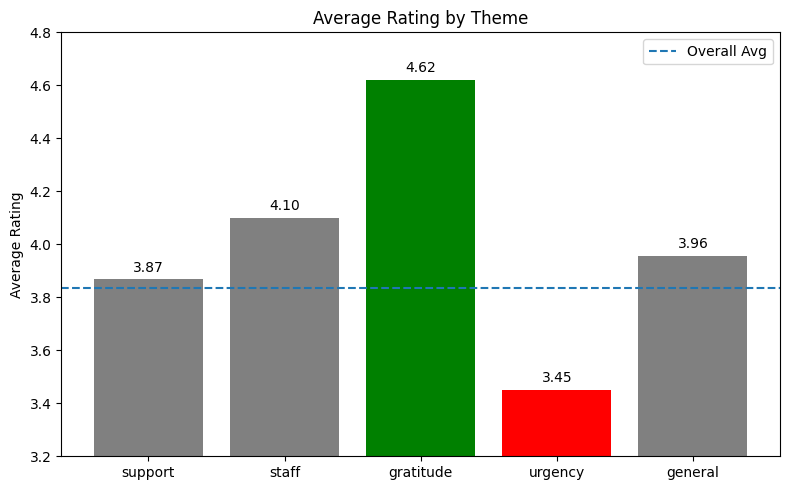

In [ ]:
themes = theme_table["Theme"]
ratings = theme_table["Avg Rating"]

colors = ["gray", "gray", "green", "red", "gray"]

plt.figure(figsize=(8,5))

bars = plt.bar(themes, ratings, color=colors)

# Add labels
for i, v in enumerate(ratings):
    plt.text(i, v + 0.03, f"{v:.2f}", ha='center')

# Reference line
overall_avg = df["review_rating"].mean()
plt.axhline(overall_avg, linestyle='--', label="Overall Avg")

plt.title("Average Rating by Theme")
plt.ylabel("Average Rating")
plt.ylim(3.2, 4.8)

plt.legend()
plt.tight_layout()
plt.show()